In [2]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

In [3]:
N1 = 1000000
kappa_range = (np.linspace(-1, 1, 20))**3
max_new = 0.115+0.003
min_new = 0.115-0.003
kappa_range = (kappa_range-kappa_range.min()) * (max_new - min_new) / 2 + min_new

num_ensambles = 3000
M1 = np.empty((len(kappa_range), num_ensambles))
for n in range(num_ensambles):
    with open('results/{0}_{1}_rho_critical.p'.format(n, N1), "rb") as f:
        mags = pickle.load(f)
        for k in range(len(kappa_range)):
            m = mags[k]
            M1[k,n] = m

In [4]:
N2 = 50000
kappa_range = (np.linspace(-1, 1, 20))**3
max_new = 0.115+0.003
min_new = 0.115-0.003
kappa_range = (kappa_range-kappa_range.min()) * (max_new - min_new) / 2 + min_new

num_ensambles = 20000
M2 = np.empty((len(kappa_range), num_ensambles))
for n in range(num_ensambles):
    with open('results/{0}_{1}_rho_critical.p'.format(n, N2), "rb") as f:
        mags = pickle.load(f)
        for k in range(len(kappa_range)):
            m = mags[k]
            M2[k,n] = m

In [5]:
N3 = 100000

num_ensambles = 10000
M3 = np.empty(num_ensambles)
for n in range(num_ensambles):
    with open('results/{0}_{1}_fig10_rho_critical.p'.format(n, N3), "rb") as f:
        mag = pickle.load(f)
        M3[n] = mag

In [6]:
N4 = 145923

num_ensambles = 10000
M4 = np.empty(num_ensambles)
for n in range(num_ensambles):
    with open('results/{0}_{1}_fig10_rho_critical.p'.format(n, N4), "rb") as f:
        mag = pickle.load(f)
        M4[n] = mag

In [7]:
N5 = 212936

num_ensambles = 10000
M5 = np.empty(num_ensambles)
for n in range(num_ensambles):
    with open('results/{0}_{1}_fig10_rho_critical.p'.format(n, N5), "rb") as f:
        mag = pickle.load(f)
        M5[n] = mag

In [8]:
N6 = 310723

num_ensambles = 10000
M6 = np.empty(num_ensambles)
for n in range(num_ensambles):
    with open('results/{0}_{1}_fig10_rho_critical.p'.format(n, N6), "rb") as f:
        mag = pickle.load(f)
        M6[n] = mag

In [26]:
m0 = 0.171405
cutoff = m0
m0_1M = m0-np.mean(M1[10][M1[10]<cutoff])
m0_50k = m0-np.mean(M2[10][M2[10]<cutoff])
m0_100k = m0-np.mean(M3[M3 < cutoff])
m0_146k = m0-np.mean(M4[M4 < cutoff])
m0_213k = m0-np.mean(M5[M5 < cutoff])
m0_311k = m0-np.mean(M6[M6 < cutoff])

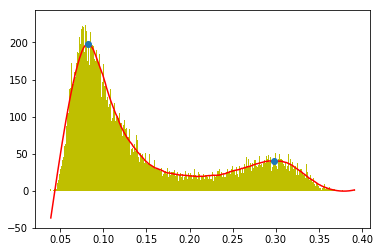

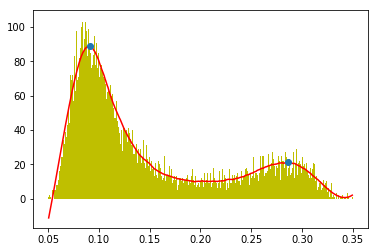

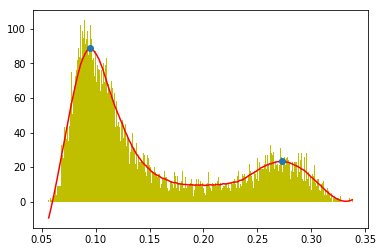

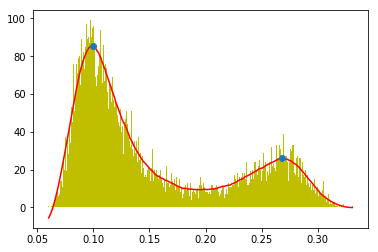

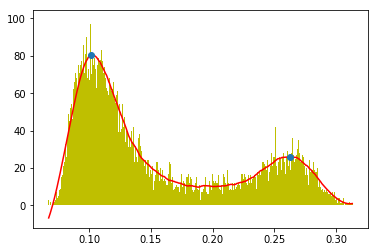

In [23]:
from scipy.signal import savgol_filter
from scipy.signal import find_peaks
#yhat = savgol_filter(y, 51, 3)

def find_peaks_(mags):
    signal, bin_edges = np.histogram(mags, bins=400)
    centres = (bin_edges[1:] + bin_edges[:-1])*0.5
    yhat = savgol_filter(signal, 81, 3)
    #yhat = savgol_filter(yhat, 21, 3)
    peaks, _ = find_peaks(yhat, distance=200)
    
    plt.hist(mags, bins=400, color='y')
    plt.plot(centres, yhat, 'r-')
    plt.plot(centres[peaks], yhat[peaks], 'o')
    plt.show()
find_peaks_(M2[10])
find_peaks_(M3)
find_peaks_(M4)
find_peaks_(M5)
find_peaks_(M6)

/home/vladimir/anaconda3/lib/python3.7/site-packages/scipy/stats/stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


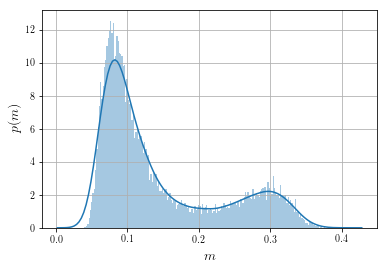

In [9]:
import seaborn as sns

plt.rc('text', usetex=True)
sns.distplot(M2[10], bins=200)
#plt.yticks([])
plt.xlabel("$m$", fontsize=14)
plt.ylabel("$p(m)$", fontsize=14)
plt.grid()
plt.show()

In [27]:
z = np.polyfit(np.log([N3, N4, N5, N6]), np.log([m0_100k, m0_146k, m0_213k, m0_311k]), 1)
print(z)
p = np.poly1d(z)

[-0.14621071 -0.9947099 ]


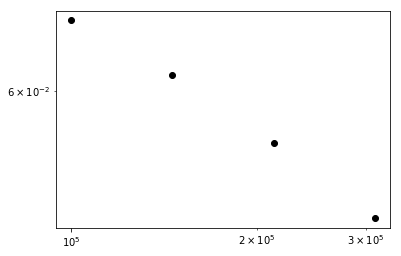

In [25]:
plt.loglog([N3, N4, N5, N6], [m0_100k, m0_146k, m0_213k, m0_311k], 'ko')
plt.show()

In [28]:
X_1M = N1*(np.mean(M1[10][M1[10]<cutoff]**2)-np.mean(M1[10][M1[10]<cutoff])**2)
X_50k = N2*(np.mean(M2[10][M2[10]<cutoff]**2)-np.mean(M2[10][M2[10]<cutoff])**2)
X_100k = N3*(np.mean(M3[M3 < cutoff]**2)-np.mean(M3[M3 < cutoff])**2)
X_146k = N4*(np.mean(M4[M4 < cutoff]**2)-np.mean(M4[M4 < cutoff])**2)
X_213k = N5*(np.mean(M5[M5 < cutoff]**2)-np.mean(M5[M5 < cutoff])**2)
X_311k = N6*(np.mean(M6[M6 < cutoff]**2)-np.mean(M6[M6 < cutoff])**2)

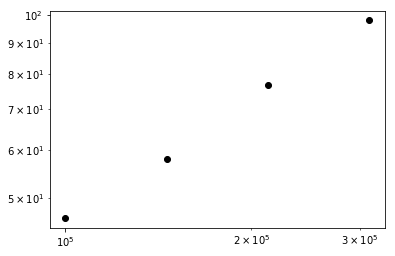

In [15]:
plt.loglog([N3, N4, N5, N6], [X_100k, X_146k, X_213k, X_311k], 'ko')
plt.show()

In [29]:
z = np.polyfit(np.log([N3, N4, N5, N6]), np.log([X_100k, X_146k, X_213k, X_311k]), 1)
print(z)
p = np.poly1d(z)

[ 0.73080411 -4.24205061]
